In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def single_negative_infonce_loss(d_pos, d_neg, temperature = 1.0):
    """
    Single-negative InfoNCE loss using cosine similarities.
    """
    z = (d_neg - d_pos) / temperature

    return np.log1p(np.exp(z))


def single_negative_infonce_gradients(d_pos, d_neg, temperature = 1.0):
    """
    Partial derivatives of the single-negative InfoNCE loss with respect to
    d_pos and d_neg.
    """
    z = (d_neg - d_pos) / temperature
    s = sigmoid(z)

    dL_dd_pos = -(1.0 / temperature) * s
    dL_dd_neg = (1.0 / temperature) * s

    return dL_dd_pos, dL_dd_neg


def make_rainbow_plot(
    temperature = 1.0,
    grid_size = 301,
    quiver_stride = 20,
    figsize = (8, 6),
    save_path = None,
    show = True,
):
    """
    Create a rainbow-style plot for single-negative InfoNCE in cosine-similarity
    space.

    Horizontal axis : d_ij = cos(anchor, positive)
    Vertical axis   : d_ik = cos(anchor, negative)

    The heatmap shows loss magnitude.
    The arrows show the gradient descent direction in (d_ij, d_ik) space.
    """
    d_pos_vals = np.linspace(-1.0, 1.0, grid_size)
    d_neg_vals = np.linspace(-1.0, 1.0, grid_size)

    D_POS, D_NEG = np.meshgrid(d_pos_vals, d_neg_vals)

    loss = single_negative_infonce_loss(D_POS, D_NEG, temperature = temperature)
    dL_dd_pos, dL_dd_neg = single_negative_infonce_gradients(
        D_POS,
        D_NEG,
        temperature = temperature,
    )

    U = -dL_dd_pos
    V = -dL_dd_neg

    fig, ax = plt.subplots(figsize = figsize)

    im = ax.imshow(
        loss,
        extent = [-1, 1, -1, 1],
        origin = "lower",
        aspect = "auto",
    )

    Xq = D_POS[::quiver_stride, ::quiver_stride]
    Yq = D_NEG[::quiver_stride, ::quiver_stride]
    Uq = U[::quiver_stride, ::quiver_stride]
    Vq = V[::quiver_stride, ::quiver_stride]

    ax.quiver(Xq, Yq, Uq, Vq, angles = "xy", scale_units = "xy", scale = None)

    ax.set_xlabel("d_ij = cos(anchor, positive)")
    ax.set_ylabel("d_ik = cos(anchor, negative)")
    ax.set_title(f"Single-negative InfoNCE rainbow plot (T = {temperature})")
    fig.colorbar(im, ax = ax, label = "Loss magnitude")

    if save_path is not None:
        fig.savefig(save_path, bbox_inches = "tight", dpi = 200)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax

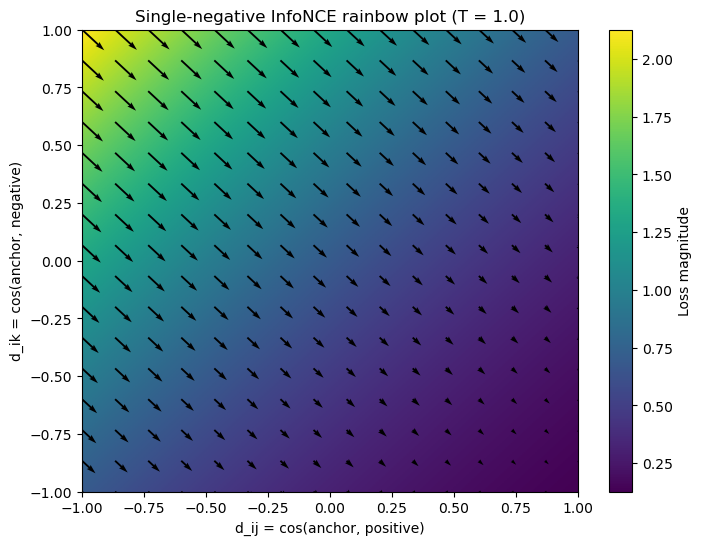

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Single-negative InfoNCE rainbow plot (T = 1.0)'}, xlabel='d_ij = cos(anchor, positive)', ylabel='d_ik = cos(anchor, negative)'>)

In [3]:
make_rainbow_plot(
    temperature = 1.0,
    grid_size = 301,
    quiver_stride = 20,
    show = True
)
